In [1]:
import os, sys, json, shutil, traceback, subprocess, re, gzip
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path
from pprint import pprint
from spm import spm_file_split

In [16]:
ENV_BIN = Path(sys.executable).parent
os.environ["PATH"] = f"{ENV_BIN}:{os.environ['PATH']}"

print("ENV_BIN:", ENV_BIN)
print("which spm:", shutil.which("spm"))

ENV_BIN: /home/bami/anaconda3/envs/JHA-spmCVR/bin
which spm: /home/bami/anaconda3/envs/JHA-spmCVR/bin/spm


In [18]:
print("sys.executable:", sys.executable)
print("ENV_BIN exists:", Path(sys.executable).parent.exists())
print("which spm:", shutil.which("spm"))
print("candidate exists:", (Path(sys.executable).parent / "spm").exists())

sys.executable: /home/bami/anaconda3/envs/JHA-spmCVR/bin/python
ENV_BIN exists: True
which spm: /home/bami/anaconda3/envs/JHA-spmCVR/bin/spm
candidate exists: True


In [2]:
## Pre-Defs

WORK_NAME = "M01_ds003768"

DATA_ROOT = Path("/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768")
RESULTS_ROOT = DATA_ROOT.parent / "rsCVR_Results"
WORK_ROOT = RESULTS_ROOT / WORK_NAME

INDEX_DIR = WORK_ROOT / "index"
LOG_DIR = WORK_ROOT / "logs"
QC_DIR = WORK_ROOT / "qc"
RAPIDTIDE_DIR = WORK_ROOT / "rapidtide"
SPM_DIR = WORK_ROOT / "spm_preproc"
SUMMARY_DIR = WORK_ROOT / "summary"
MANIFEST_DIR = WORK_ROOT / "manifests"

for d in [RESULTS_ROOT, WORK_ROOT, INDEX_DIR, LOG_DIR, QC_DIR, RAPIDTIDE_DIR, SPM_DIR, SUMMARY_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT   :", DATA_ROOT)
print("WORK_ROOT   :", WORK_ROOT)

DATA_ROOT   : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768
WORK_ROOT   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768


In [3]:
# Defs
def load_json_safe(p):
    p = Path(p)
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(obj, p):
    p = Path(p)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def nifti_info(p):
    img = nib.load(str(p))
    shape = img.shape
    zooms = img.header.get_zooms()
    return {
        "shape": shape,
        "zooms": zooms,
        "ndim": len(shape),
    }

# Defs for QC
def save_mean_bold(bold_path, out_path):
    img = nib.load(str(bold_path))
    data = img.get_fdata(dtype=np.float32)

    if data.ndim == 4:
        mean_data = data.mean(axis=-1)
    else:
        mean_data = data

    out_img = nib.Nifti1Image(mean_data, img.affine, img.header)
    nib.save(out_img, str(out_path))
    return out_path

def middle_slices(vol3d):
    x, y, z = vol3d.shape
    return vol3d[x//2, :, :], vol3d[:, y//2, :], vol3d[:, :, z//2]

def plot_orthogonal(vol3d, title="", out_png=None):
    sag, cor, axi = middle_slices(vol3d)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(np.rot90(sag), cmap="gray")
    axes[0].set_title("Sagittal")
    axes[0].axis("off")

    axes[1].imshow(np.rot90(cor), cmap="gray")
    axes[1].set_title("Coronal")
    axes[1].axis("off")

    axes[2].imshow(np.rot90(axi), cmap="gray")
    axes[2].set_title("Axial")
    axes[2].axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    if out_png is not None:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)

def plot_before_after_orthogonal(before_img_path, after_img_path, title="", out_png=None):
    before = nib.load(str(before_img_path)).get_fdata()
    after = nib.load(str(after_img_path)).get_fdata()

    b_sag, b_cor, b_axi = middle_slices(before)
    a_sag, a_cor, a_axi = middle_slices(after)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    axes[0, 0].imshow(np.rot90(b_sag), cmap="gray")
    axes[0, 0].set_title("Before - Sagittal")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(np.rot90(b_cor), cmap="gray")
    axes[0, 1].set_title("Before - Coronal")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(np.rot90(b_axi), cmap="gray")
    axes[0, 2].set_title("Before - Axial")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(np.rot90(a_sag), cmap="gray")
    axes[1, 0].set_title("After - Sagittal")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(np.rot90(a_cor), cmap="gray")
    axes[1, 1].set_title("After - Coronal")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(np.rot90(a_axi), cmap="gray")
    axes[1, 2].set_title("After - Axial")
    axes[1, 2].axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    if out_png is not None:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)


In [6]:
# Select subject :: for realignment trial

TEST_SUBJECT = "sub-01"
TEST_RUNS = ["run-1", "run-2"]
# df_test = df_runs[(df_runs["subject"] == TEST_SUBJECT) & (df_runs["run"].isin(TEST_RUNS))].copy()
# assert len(df_test) == 2, f"Expected 2 rows for {TEST_SUBJECT}, got {len(df_test)}"

# df_test

In [7]:
# Build per-run execution specs

run_specs = []

for run in TEST_RUNS:
    subj_dir = DATA_ROOT / TEST_SUBJECT
    anat_dir = subj_dir / "anat"
    func_dir = subj_dir / "func"

    t1_nii = anat_dir / f"{TEST_SUBJECT}_T1w.nii.gz"
    t1_json = anat_dir / f"{TEST_SUBJECT}_T1w.json"

    bold_nii = func_dir / f"{TEST_SUBJECT}_task-rest_{run}_bold.nii.gz"
    bold_json = func_dir / f"{TEST_SUBJECT}_task-rest_{run}_bold.json"

    meta = load_json_safe(bold_json)

    spm_subject_root = SPM_DIR / TEST_SUBJECT
    spm_anat_dir = spm_subject_root / "anat"
    spm_run_dir = spm_subject_root / run

    rapidtide_subject_root = RAPIDTIDE_DIR / TEST_SUBJECT
    rapidtide_run_dir = rapidtide_subject_root / run

    qc_subject_root = QC_DIR / TEST_SUBJECT
    qc_run_dir = qc_subject_root / run

    for d in [spm_subject_root, spm_anat_dir, spm_run_dir, rapidtide_subject_root, rapidtide_run_dir, qc_subject_root, qc_run_dir]:
        d.mkdir(parents=True, exist_ok=True)

    spec = {
        "subject": TEST_SUBJECT,
        "run": run,
        "inputs": {
            "t1_nii": str(t1_nii),
            "t1_json": str(t1_json),
            "bold_nii": str(bold_nii),
            "bold_json": str(bold_json),
            "TR": float(meta.get("RepetitionTime")),
        },
        "outputs": {
            "spm_subject_root": str(spm_subject_root),
            "spm_anat_dir": str(spm_anat_dir),
            "spm_run_dir": str(spm_run_dir),
            "spm_preproc_bold": str(spm_run_dir / f"{TEST_SUBJECT}_{run}_preproc_bold.nii.gz"),
            "spm_motion_tsv": str(spm_run_dir / f"{TEST_SUBJECT}_{run}_motion.tsv"),
            "spm_brainmask": str(spm_run_dir / f"{TEST_SUBJECT}_{run}_brainmask.nii.gz"),
            "rapidtide_run_dir": str(rapidtide_run_dir),
            "rapidtide_output_root": str(rapidtide_run_dir / f"{TEST_SUBJECT}_{run}"),
            "qc_run_dir": str(qc_run_dir),
            "qc_summary_json": str(qc_run_dir / f"{TEST_SUBJECT}_{run}_qc_summary.json"),
            "t1_qc_png": str(qc_run_dir / f"{TEST_SUBJECT}_{run}_t1_orth.png"),
            "mean_bold_qc_png": str(qc_run_dir / f"{TEST_SUBJECT}_{run}_meanbold_orth.png"),
        },
        "derived_inputs": {
            "mean_bold": str(spm_run_dir / f"{TEST_SUBJECT}_{run}_mean_bold.nii.gz"),
        },
        "nifti_info": nifti_info(bold_nii),
    }
    run_specs.append(spec)

len(run_specs), run_specs[0]["run"], run_specs[1]["run"]

(2, 'run-1', 'run-2')

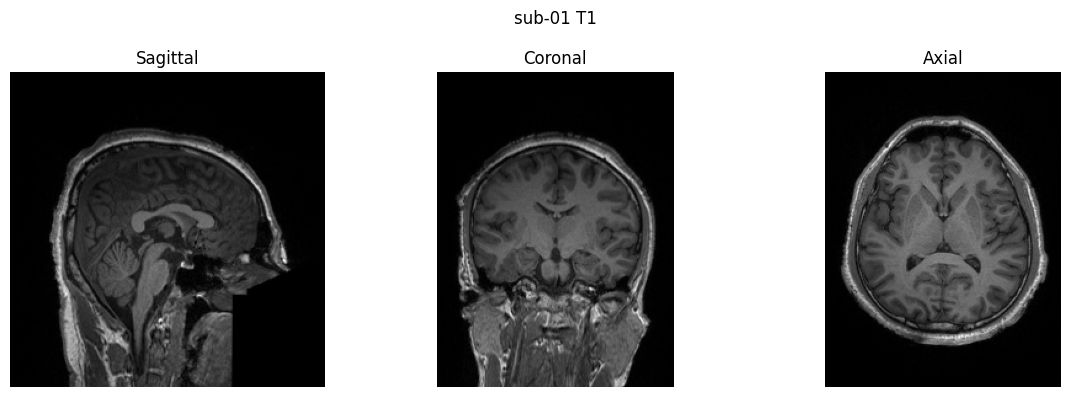

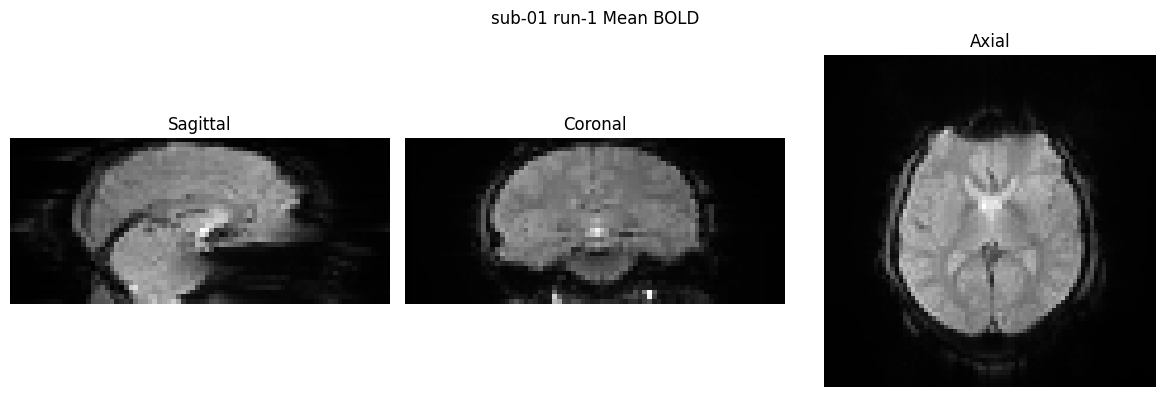

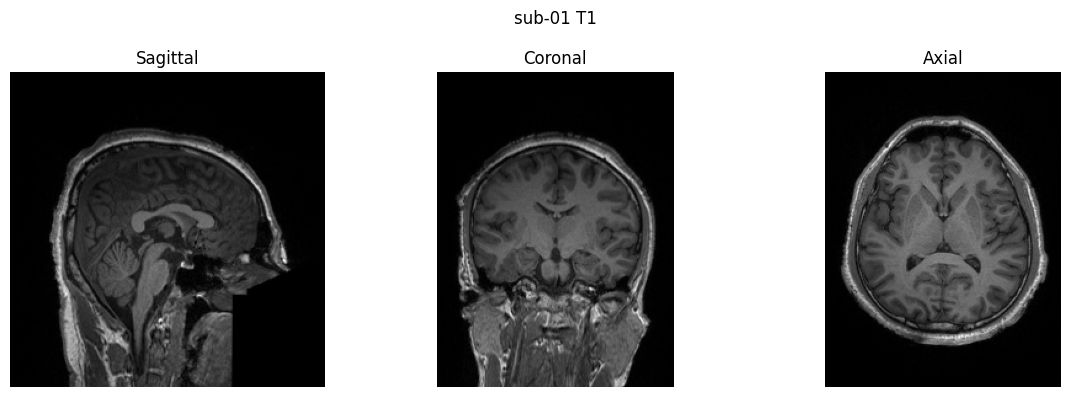

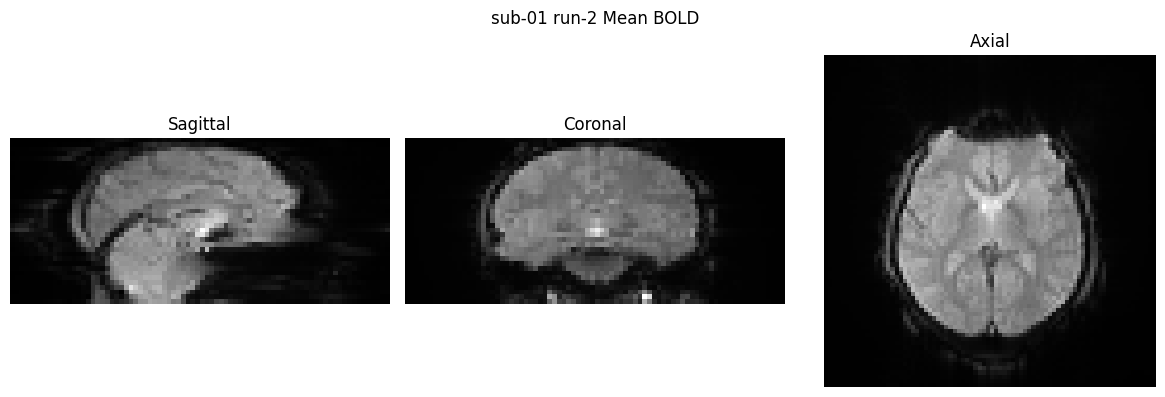

Mean-BOLD & QC figures created for both runs.


In [8]:
# Generate mean-BOLD and QC imgs (both run)

for spec in run_specs:
    t1_nii = Path(spec["inputs"]["t1_nii"])
    bold_nii = Path(spec["inputs"]["bold_nii"])
    mean_bold_path = Path(spec["derived_inputs"]["mean_bold"])
    t1_qc_png = Path(spec["outputs"]["t1_qc_png"])
    mean_bold_qc_png = Path(spec["outputs"]["mean_bold_qc_png"])

    save_mean_bold(bold_nii, mean_bold_path)

    t1_img = nib.load(str(t1_nii))
    mean_bold_img = nib.load(str(mean_bold_path))

    plot_orthogonal(t1_img.get_fdata(), title=f"{spec['subject']} T1", out_png=t1_qc_png)
    plot_orthogonal(mean_bold_img.get_fdata(), title=f"{spec['subject']} {spec['run']} Mean BOLD", out_png=mean_bold_qc_png)

print("Mean-BOLD & QC figures created for both runs.")

In [17]:
# Prepare BOLD imgs

def prepare_bold_for_spm(spec):
    spm_run_dir = Path(spec["outputs"]["spm_run_dir"])
    src_gz = Path(spec["inputs"]["bold_nii"])

    local_gz = spm_run_dir / src_gz.name
    local_nii = spm_run_dir / src_gz.name.replace(".nii.gz", ".nii")

    shutil.copy2(src_gz, local_gz)

    if local_nii.exists():
        local_nii.unlink()

    with gzip.open(local_gz, "rb") as f_in, open(local_nii, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

    return {
        "local_gz": str(local_gz),
        "local_nii": str(local_nii),
    }

def split_4d_to_3d(local_nii: Path, out_dir: Path):
    local_nii = Path(local_nii)
    out_dir = Path(out_dir)

    stem = local_nii.stem
    for p in out_dir.glob(f"{stem}_*.nii"):
        p.unlink()

    spm_file_split(str(local_nii), str(out_dir))

    split_files = sorted(out_dir.glob(f"{stem}_*.nii"))
    if not split_files:
        raise RuntimeError(f"No split 3D files created from {local_nii}")

    return [str(p) for p in split_files]


# Batch writer
def write_spm_realign_estwrite_job(split_scans, job_m_path):
    split_scans = [str(Path(p)).replace("\\", "/") for p in split_scans]
    job_m_path = Path(job_m_path)

    scan_block = "\n".join([f"    '{p},1'" for p in split_scans])

    job_txt = f"""
matlabbatch{{1}}.spm.spatial.realign.estwrite.data{{1}} = {{
{scan_block}
}};

matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.quality = 0.9;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.sep = 4;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.fwhm = 5;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.rtm = 1;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.interp = 2;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.wrap = [0 0 0];
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.weight = '';

matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.which = [2 1];
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.interp = 4;
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.wrap = [0 0 0];
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.mask = 1;
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.prefix = 'r';

spm('defaults', 'fmri');
spm_jobman('initcfg');
spm_jobman('run', matlabbatch);
"""
    job_m_path.write_text(job_txt.strip() + "\n", encoding="utf-8")
    return job_m_path

# CLI Runner
def run_spm_job_via_cli(job_m_path, cwd=None):
    import os, sys, shutil
    from pathlib import Path

    job_m_path = Path(job_m_path)

    spm_exe = shutil.which("spm")

    if spm_exe is None:
        env_bin = Path(sys.executable).parent
        candidate = env_bin / "spm"
        if candidate.exists():
            spm_exe = str(candidate)

    if spm_exe is None:
        raise FileNotFoundError(
            f"SPM CLI executable not found. "
            f"sys.executable={sys.executable}, PATH={os.environ.get('PATH', '')}"
        )

    cmd = [spm_exe, "script", str(job_m_path)]

    out = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        cwd=cwd,
        check=False
    )
    return {
        "cmd": cmd,
        "spm_exe": spm_exe,
        "returncode": out.returncode,
        "stdout": out.stdout,
        "stderr": out.stderr,
    }

# 3D to 4D merging
def merge_3d_to_4d_nifti(realigned_files, out_path):
    realigned_files = [str(Path(p)) for p in realigned_files]
    imgs = [nib.load(p) for p in realigned_files]
    data = np.stack([img.get_fdata(dtype=np.float32) for img in imgs], axis=-1)

    out_path = Path(out_path)
    affine = imgs[0].affine
    header = imgs[0].header.copy()

    img4d = nib.Nifti1Image(data, affine, header=header)
    nib.save(img4d, str(out_path))
    return out_path

In [19]:
# # Clean-up :: 기존 파일 삭제
for spec in run_specs:
    run_dir = Path(spec["outputs"]["spm_run_dir"])

    for pattern in ["rp_*.txt", "r*.nii", "mean*.nii", "*_000*.nii", "*.mat", "*realign_estwrite_job.m"]:
        for p in run_dir.glob(pattern):
            try:
                p.unlink()
            except Exception:
                pass

    for p in [
        Path(spec["outputs"]["spm_motion_tsv"]),
        Path(spec["outputs"]["spm_preproc_bold"]),
    ]:
        if p.exists():
            try:
                p.unlink()
            except Exception:
                pass

In [11]:
# Execution

def run_spm_realign_trial(spec: dict, execute: bool = False, show_qc: bool = True):
    result = {
        "subject": spec["subject"],
        "run": spec["run"],
        "execute": execute,
        "success": False,
        "prepared_local_files": None,
        "generated_files": {},
        "qc_files": {},
        "error": None,
    }

    try:
        spm_run_dir = Path(spec["outputs"]["spm_run_dir"])
        qc_run_dir = Path(spec["outputs"]["qc_run_dir"])
        qc_run_dir.mkdir(parents=True, exist_ok=True)

        prepared = prepare_bold_for_spm(spec)
        local_nii = Path(prepared["local_nii"])
        local_gz = Path(prepared["local_gz"])
        result["prepared_local_files"] = prepared

        pre_mean_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_mean_before_realign.nii.gz"
        save_mean_bold(local_nii, pre_mean_path)

        if not execute:
            img = nib.load(str(local_nii))
            result["generated_files"] = {
                "local_gz": str(local_gz),
                "local_nii": str(local_nii),
                "n_scans": int(img.shape[3]),
                "mean_before_realign": str(pre_mean_path),
            }
            result["success"] = True
            return result

        split_scans = split_4d_to_3d(local_nii, spm_run_dir)

        job_m_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_realign_estwrite_job.m"
        write_spm_realign_estwrite_job(split_scans, job_m_path)

        job_result = run_spm_job_via_cli(job_m_path, cwd=spm_run_dir)

        generated = {}
        generated["local_gz"] = str(local_gz)
        generated["local_nii"] = str(local_nii)
        generated["split_scans"] = split_scans
        generated["spm_job_m"] = str(job_m_path)
        generated["spm_job_returncode"] = job_result["returncode"]
        generated["spm_job_stdout_tail"] = job_result["stdout"][-3000:]
        generated["spm_job_stderr_tail"] = job_result["stderr"][-3000:]

        if job_result["returncode"] != 0:
            raise RuntimeError(
                f"SPM batch job failed\nSTDOUT:\n{job_result['stdout']}\nSTDERR:\n{job_result['stderr']}"
            )

        generated["realigned_files"] = sorted([str(p) for p in spm_run_dir.glob("r*.nii")])
        generated["mean_files"] = sorted([str(p) for p in spm_run_dir.glob("mean*.nii")])

        if len(generated["realigned_files"]) >= 1:
            dst_4d = Path(spec["outputs"]["spm_preproc_bold"])
            merge_3d_to_4d_nifti(generated["realigned_files"], dst_4d)
            generated["standard_preproc_bold"] = str(dst_4d)
        else:
            generated["standard_preproc_bold"] = None

        rp_candidates = sorted(spm_run_dir.glob("rp_*.txt"))
        generated["motion_files_txt"] = [str(p) for p in rp_candidates]

        motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])
        if len(rp_candidates) == 1:
            df_motion = pd.read_csv(rp_candidates[0], sep=r"\s+", header=None)
            df_motion.columns = ["x", "y", "z", "pitch", "roll", "yaw"]
            df_motion.to_csv(motion_tsv, sep="\t", index=False)

            generated["standard_motion_tsv"] = str(motion_tsv)
            generated["motion_n_rows"] = int(df_motion.shape[0])
        else:
            generated["standard_motion_tsv"] = None
            generated["motion_n_rows"] = 0
            generated["motion_error"] = f"Expected exactly 1 rp_*.txt file, found {len(rp_candidates)}"

        qc_files = {}

        if len(generated["mean_files"]) == 1:
            post_mean_path = Path(generated["mean_files"][0])
            realign_compare_png = qc_run_dir / f"{spec['subject']}_{spec['run']}_realign_before_after.png"

            plot_before_after_orthogonal(
                before_img_path=pre_mean_path,
                after_img_path=post_mean_path,
                title=f"{spec['subject']} {spec['run']} - Realign: Before vs After",
                out_png=realign_compare_png
            )
            qc_files["realign_before_after_png"] = str(realign_compare_png)

        if generated.get("standard_preproc_bold"):
            standard_preproc_bold = Path(generated["standard_preproc_bold"])
            post_reslice_mean_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_mean_after_reslice.nii.gz"
            save_mean_bold(standard_preproc_bold, post_reslice_mean_path)

            reslice_compare_png = qc_run_dir / f"{spec['subject']}_{spec['run']}_reslice_before_after.png"
            plot_before_after_orthogonal(
                before_img_path=pre_mean_path,
                after_img_path=post_reslice_mean_path,
                title=f"{spec['subject']} {spec['run']} - Reslice: Before vs After",
                out_png=reslice_compare_png
            )
            qc_files["mean_after_reslice"] = str(post_reslice_mean_path)
            qc_files["reslice_before_after_png"] = str(reslice_compare_png)

        if show_qc:
            if pre_mean_path.exists():
                plot_orthogonal(
                    nib.load(str(pre_mean_path)).get_fdata(),
                    title=f"{spec['subject']} {spec['run']} Mean Before Realign"
                )

            if len(generated["mean_files"]) == 1:
                plot_orthogonal(
                    nib.load(generated["mean_files"][0]).get_fdata(),
                    title=f"{spec['subject']} {spec['run']} Mean After Realign"
                )

        result["generated_files"] = generated
        result["qc_files"] = qc_files

        result["success"] = (
            generated["spm_job_returncode"] == 0
            and len(generated["realigned_files"]) >= 1
            and len(generated["mean_files"]) == 1
            and len(generated["motion_files_txt"]) == 1
            and generated.get("motion_n_rows", 0) > 1
        )

        if not result["success"] and "motion_error" not in generated:
            generated["motion_error"] = "Run completed, but output structure did not match expected final form."

        return result

    except Exception:
        result["error"] = traceback.format_exc()
        return result


# realign_trial_dry_results = []
# for spec in run_specs:
#     res = run_spm_realign_trial(spec, execute=False)
#     realign_trial_dry_results.append(res)

# realign_trial_dry_results

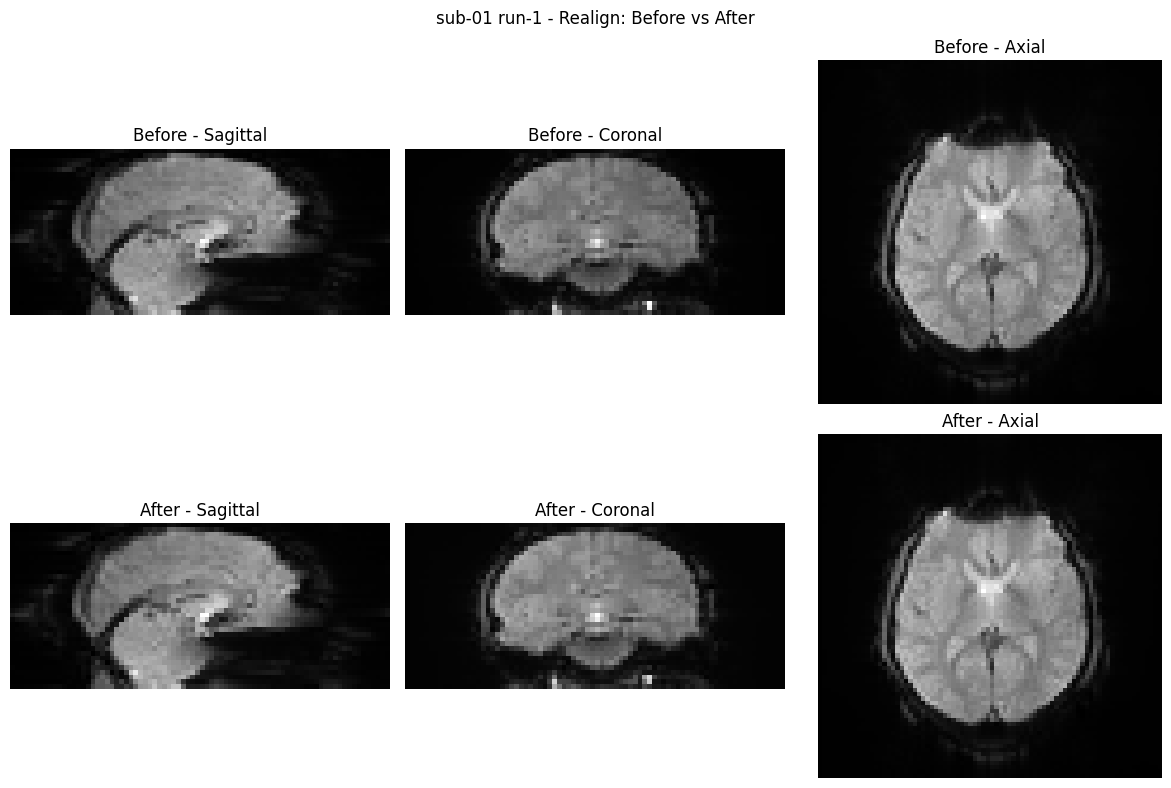

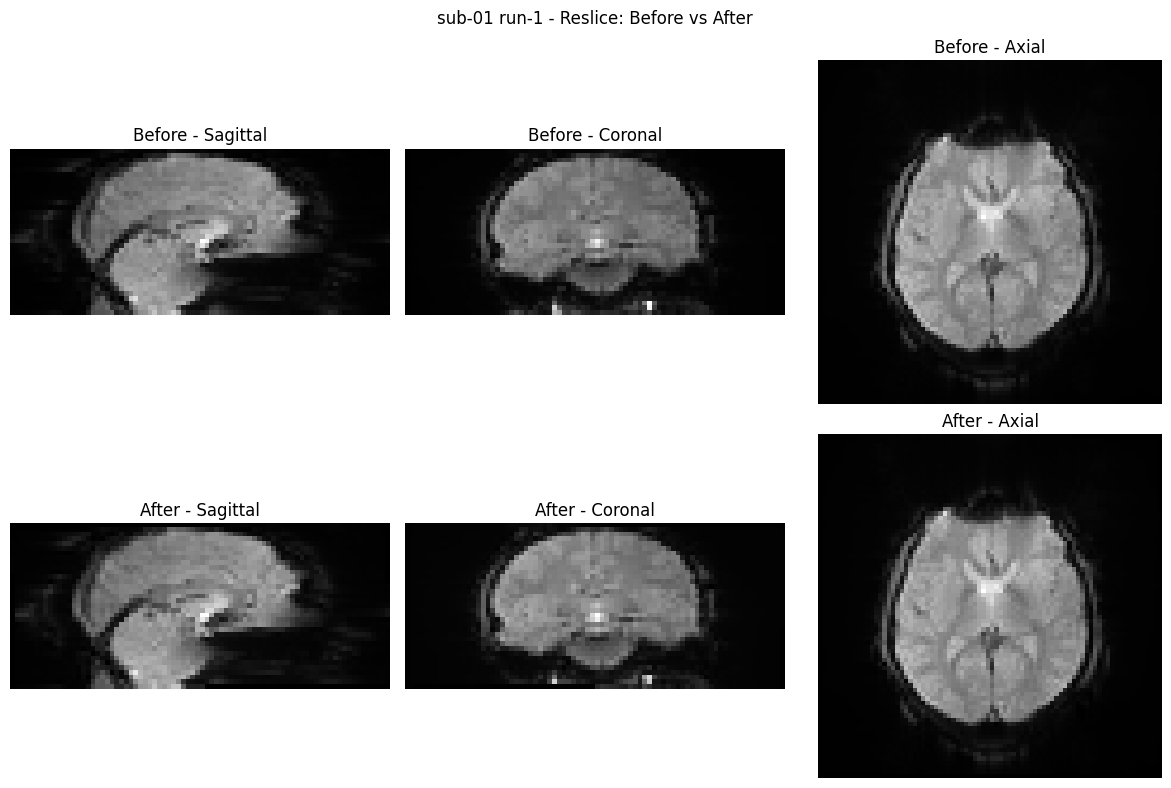

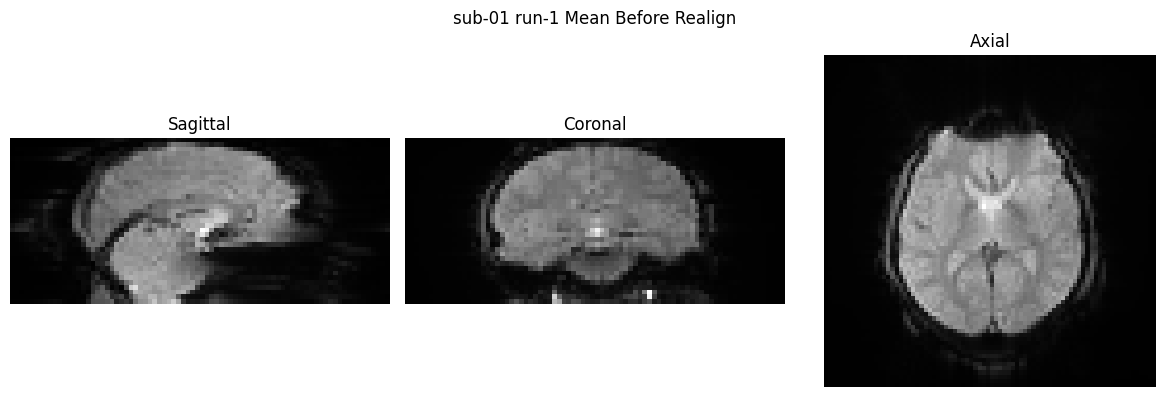

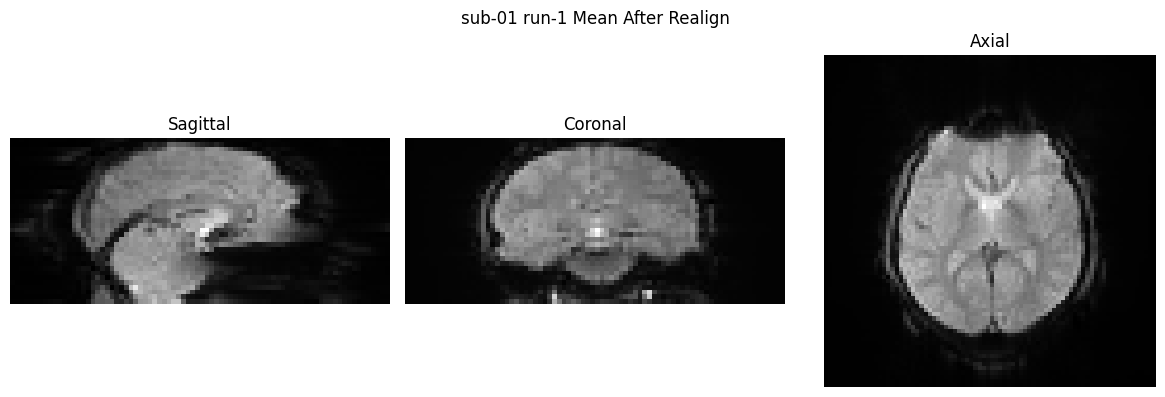

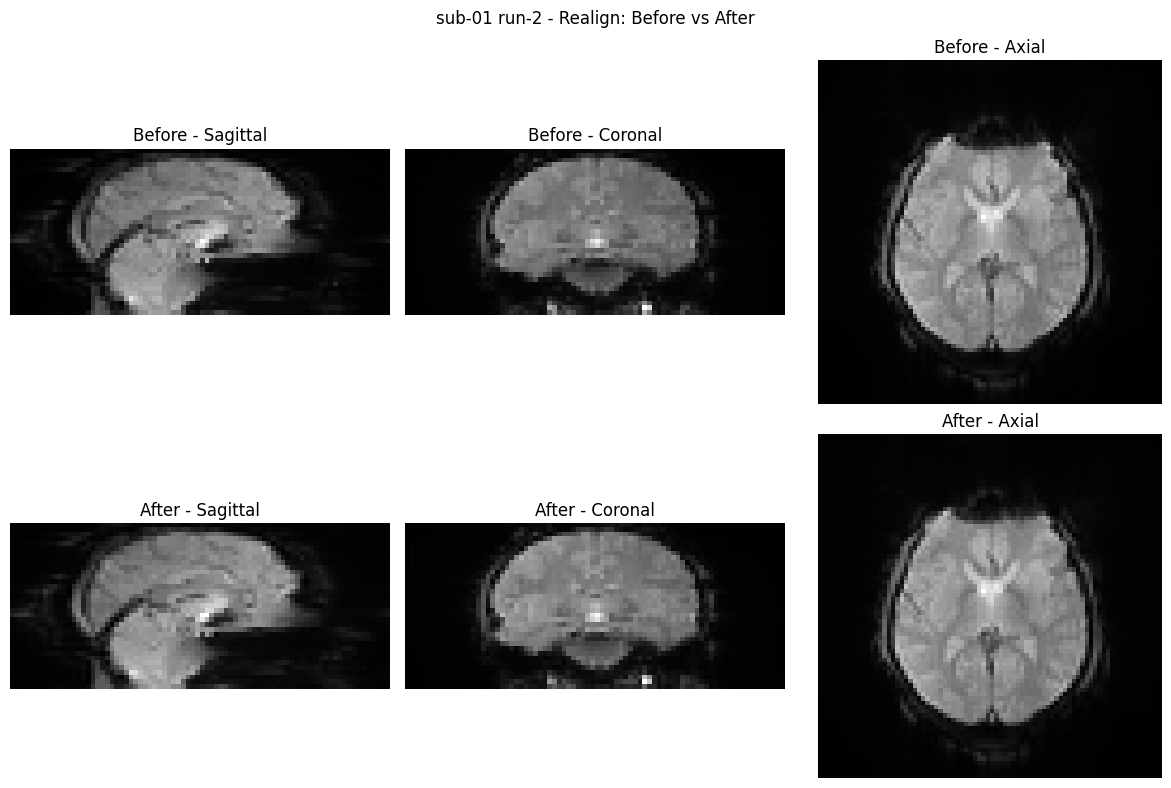

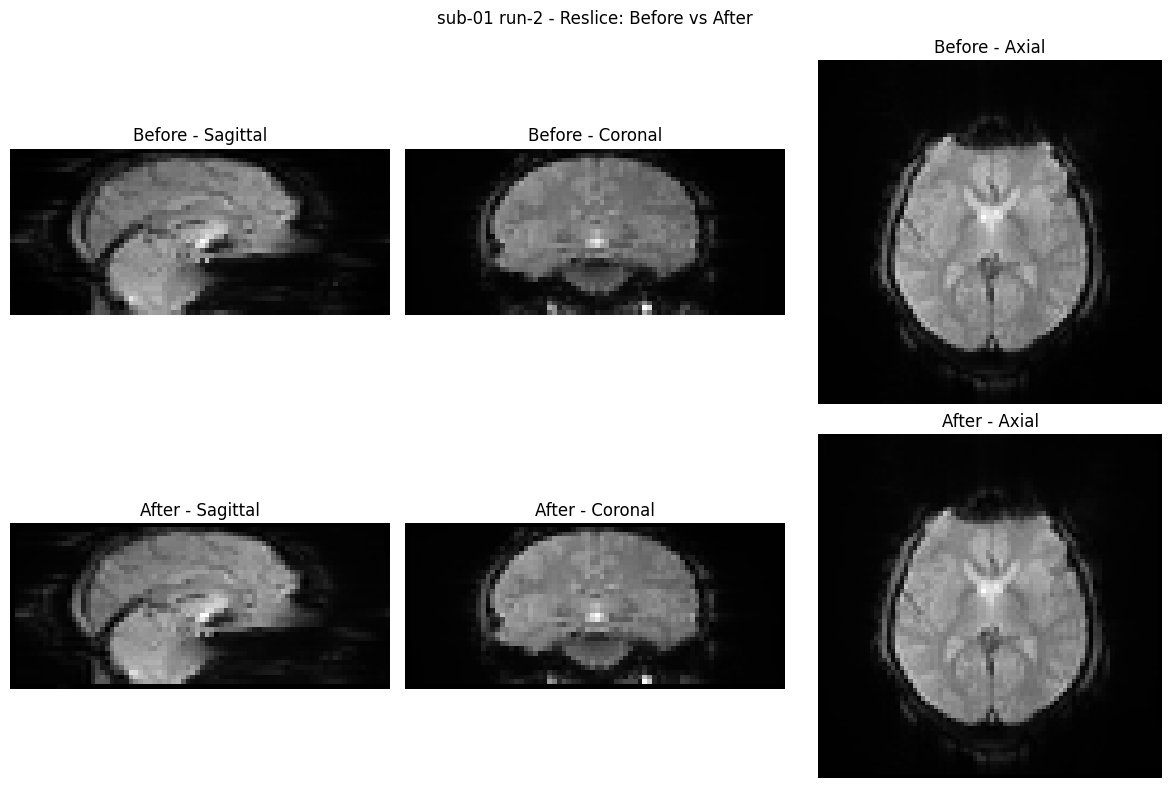

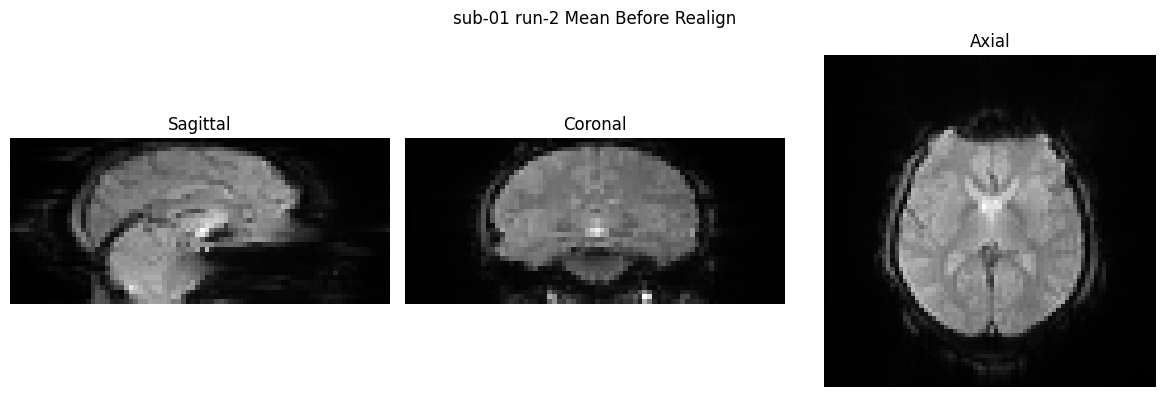

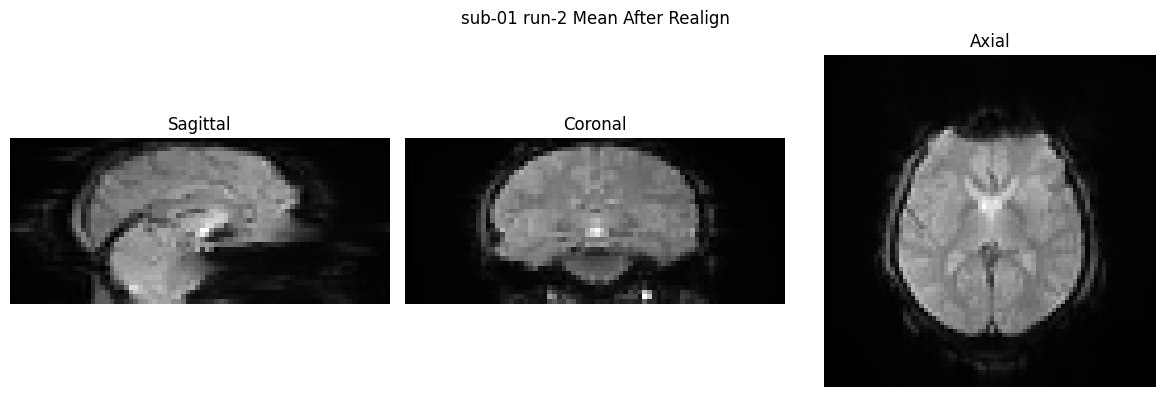

[{'subject': 'sub-01',
  'run': 'run-1',
  'execute': True,
  'success': True,
  'prepared_local_files': {'local_gz': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii.gz',
   'local_nii': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii'},
  'generated_files': {'local_gz': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii.gz',
   'local_nii': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii',
   'split_scans': ['/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold_00001.nii',
    '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold_00002.nii',
    '/media/bami/JHA/rsCVR/dat

In [20]:
#### Execute realignment (both runs)

realign_trial_exec_results = []
for spec in run_specs:
    res = run_spm_realign_trial(spec, execute=True, show_qc=True)
    realign_trial_exec_results.append(res)

realign_trial_exec_results

In [23]:
for res in realign_trial_exec_results:
    print("\n====================")
    print(res["subject"], res["run"])
    print("success:", res["success"])
    print("error:", res["error"])

    gf = res["generated_files"]
    print("n_realigned_files:", len(gf.get("realigned_files", [])))
    print("n_mean_files     :", len(gf.get("mean_files", [])))
    print("n_motion_txt     :", len(gf.get("motion_files_txt", [])))
    print("motion_n_rows    :", gf.get("motion_n_rows", None))
    print("motion_error     :", gf.get("motion_error", None))


sub-01 run-1
success: True
error: None
n_realigned_files: 286
n_mean_files     : 1
n_motion_txt     : 1
motion_n_rows    : 286
motion_error     : None

sub-01 run-2
success: True
error: None
n_realigned_files: 286
n_mean_files     : 1
n_motion_txt     : 1
motion_n_rows    : 286
motion_error     : None


In [27]:
for spec in run_specs:
    motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])
    print(f"\n===== {spec['subject']} {spec['run']} : FD summary =====")

    if not motion_tsv.exists():
        print("motion.tsv not found")
        continue

    df_mot = pd.read_csv(motion_tsv, sep="\t")
    fd = compute_fd_power(df_mot, radius_mm=50.0)

    print(fd.describe().round(6))


===== sub-01 run-1 : FD summary =====
count    286.000000
mean       0.270301
std        0.108687
min        0.000000
25%        0.185371
50%        0.265934
75%        0.341831
max        0.823456
dtype: float64

===== sub-01 run-2 : FD summary =====
count    286.000000
mean       0.200071
std        0.377483
min        0.000000
25%        0.074613
50%        0.112391
75%        0.164870
max        3.836198
dtype: float64


In [24]:
for spec in run_specs:
    motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])
    print(f"\n{spec['subject']} {spec['run']} ::")

    if motion_tsv.exists():
        df_mot = pd.read_csv(motion_tsv, sep="\t")
        print("shape:", df_mot.shape)
        print(df_mot)
    else:
        print("motion.tsv not found")


sub-01 run-1 ::
shape: (286, 6)
            x         y         z     pitch      roll       yaw
0    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1    0.001106 -0.024036  0.075431  0.000567  0.000300 -0.000147
2    0.008688 -0.046443  0.093721 -0.000469 -0.000529  0.000315
3    0.023464 -0.073644  0.037877 -0.000420 -0.003005 -0.000398
4    0.007337 -0.051277  0.049352 -0.001852 -0.004355 -0.000730
..        ...       ...       ...       ...       ...       ...
281 -0.155334  0.189087 -0.257747 -0.011523 -0.014145 -0.000176
282 -0.122666  0.274059 -0.148740 -0.010131 -0.013698 -0.000328
283 -0.150531  0.175890 -0.211843 -0.011327 -0.014635 -0.000489
284 -0.114347  0.265655 -0.185121 -0.010566 -0.013630 -0.000337
285 -0.151122  0.109934 -0.204224 -0.012533 -0.014598 -0.000726

[286 rows x 6 columns]

sub-01 run-2 ::
shape: (286, 6)
            x         y         z     pitch      roll       yaw
0    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1    0.509102 

In [25]:
# Max Trans/Rotation summary of each Run

for spec in run_specs:
    motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])
    print(f"\n{spec['subject']} {spec['run']} : max motion summary :: :  :")

    if not motion_tsv.exists():
        print("motion.tsv not found")
        continue

    df_mot = pd.read_csv(motion_tsv, sep="\t")

    trans_cols = ["x", "y", "z"]
    rot_cols = ["pitch", "roll", "yaw"]

    max_abs_trans = df_mot[trans_cols].abs().max()
    max_abs_rot = df_mot[rot_cols].abs().max()

    print("Max |translation|")
    print(max_abs_trans)
    print("\nMax |rotation|")
    print(max_abs_rot)

    print("\nOverall max translation (mm-ish):", max_abs_trans.max())
    print("Overall max rotation (rad):", max_abs_rot.max())


sub-01 run-1 : max motion summary :: :  :
Max |translation|
x    0.206459
y    0.317401
z    0.321533
dtype: float64

Max |rotation|
pitch    0.014581
roll     0.016473
yaw      0.002788
dtype: float64

Overall max translation (mm-ish): 0.3215334
Overall max rotation (rad): 0.016473099

sub-01 run-2 : max motion summary :: :  :
Max |translation|
x    0.630594
y    2.381688
z    0.783364
dtype: float64

Max |rotation|
pitch    0.015926
roll     0.020389
yaw      0.010348
dtype: float64

Overall max translation (mm-ish): 2.3816881
Overall max rotation (rad): 0.020389219


In [26]:
def compute_fd_power(df_motion, radius_mm=50.0):
    df = df_motion.copy()

    diff = df[["x", "y", "z", "pitch", "roll", "yaw"]].diff().fillna(0.0)

    # rotation(rad) -> arc length(mm)
    for col in ["pitch", "roll", "yaw"]:
        diff[col] = diff[col].abs() * radius_mm

    for col in ["x", "y", "z"]:
        diff[col] = diff[col].abs()

    fd = diff.sum(axis=1)
    return fd


summary_rows = []

for spec in run_specs:
    motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])

    if not motion_tsv.exists():
        summary_rows.append({
            "subject": spec["subject"],
            "run": spec["run"],
            "n_frames": None,
            "mean_FD": None,
            "max_FD": None,
            "n_FD_gt_0p2": None,
            "n_FD_gt_0p5": None,
            "max_abs_x": None,
            "max_abs_y": None,
            "max_abs_z": None,
            "max_abs_pitch": None,
            "max_abs_roll": None,
            "max_abs_yaw": None,
        })
        continue

    df_mot = pd.read_csv(motion_tsv, sep="\t")
    fd = compute_fd_power(df_mot, radius_mm=50.0)

    summary_rows.append({
        "subject": spec["subject"],
        "run": spec["run"],
        "n_frames": len(df_mot),
        "mean_FD": fd.mean(),
        "max_FD": fd.max(),
        "n_FD_gt_0p2": int((fd > 0.2).sum()),
        "n_FD_gt_0p5": int((fd > 0.5).sum()),
        "max_abs_x": df_mot["x"].abs().max(),
        "max_abs_y": df_mot["y"].abs().max(),
        "max_abs_z": df_mot["z"].abs().max(),
        "max_abs_pitch": df_mot["pitch"].abs().max(),
        "max_abs_roll": df_mot["roll"].abs().max(),
        "max_abs_yaw": df_mot["yaw"].abs().max(),
    })

df_motion_summary = pd.DataFrame(summary_rows)
df_motion_summary

,subject,run,n_frames,mean_FD,max_FD,n_FD_gt_0p2,n_FD_gt_0p5,max_abs_x,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw
0,sub-01,run-1,286,0.270301,0.823456,209,4,0.206459,0.317401,0.321533,0.014581,0.016473,0.002788
1,sub-01,run-2,286,0.200071,3.836198,51,17,0.630594,2.381688,0.783364,0.015926,0.020389,0.010348
